In [278]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output directory
outdir = "plots"
if not os.path.exists(outdir):
    os.makedirs(outdir)

In [279]:
def load_timing_data():
    """Load timing data from CSV files"""
    
    # Load the CSV files
    bridge_df = pd.read_csv("Video Analysis - Timings_Bridge.csv")
    laptop_df = pd.read_csv("Video Analysis - Timings_Laptop.csv")

    # Change order so that 'MIDI Connection' comes after 'OSC Configuration'
    if 'MIDI Connection' in bridge_df.columns:
        # Change order
        bridge_df = bridge_df[['User ID','Device', 'Room', 'Bootstrap', 'WiFi Config', 'OSC Configuration', 'MIDI Connection', 'Wifi+OSC', 'Tot']]
    if 'MIDI Connection' in laptop_df.columns:
        # Change order
        laptop_df = laptop_df[['User ID','Device', 'Room', 'Bootstrap', 'WiFi Config', 'OSC Configuration', 'MIDI Connection', 'Wifi+OSC', 'Tot']]

    
    # Combine data with device labels
    bridge_df['Device'] = 'Bridge'
    laptop_df['Device'] = 'Laptop'
    
    return bridge_df, laptop_df

def calculate_stats(data, columns):
    """Calculate mean and standard error for specified columns"""
    means = data[columns].mean()
    std_errors = data[columns].sem()  # Standard error of the mean
    return means, std_errors

In [280]:
# Load data
bridge_data, laptop_data = load_timing_data()

print(f"Loaded {len(bridge_data)} bridge measurements and {len(laptop_data)} laptop measurements")

# Define timing columns
all_timing_columns = ['Bootstrap', 'WiFi Config', 'OSC Configuration', 'MIDI Connection']
selected_timing_columns = ['Bootstrap', 'Wifi+OSC', 'MIDI Connection', 'Tot']
selected_delta_columns = ['Delta_Bootstrap', 'Delta_WifiAndOSC_Config', 'Delta_MIDI_Connection', 'Delta_Tot']

matplotlib_boldtext = lambda text: r'$\bf{' + text + r'}$'

label_names = {
    'Bootstrap': 'Bootstrap',
    'WiFi Config': 'WiFi\nConfiguration',
    'OSC Configuration': 'OSC\nConfiguration',
    'MIDI Connection': 'MIDI\nConnection',
    'Wifi+OSC': 'Configuration\n(WiFi+OSC)',
    'Tot': matplotlib_boldtext('Total'),
    'Delta_Bootstrap': 'Δ Bootstrap',
    'Delta_WiFi_Config': 'Δ WiFi\nConfiguration',
    'Delta_OSC_Config': 'Δ OSC\nConfiguration',
    'Delta_WifiAndOSC_Config': 'Δ Wifi+OSC\nConfiguration',
    'Delta_MIDI_Connection': 'Δ MIDI\nConnection',
    'Delta_Tot': 'Δ Total'
}

# Calculate statistics for all timing columns
bridge_means_all, bridge_errors_all = calculate_stats(bridge_data, all_timing_columns)
laptop_means_all, laptop_errors_all = calculate_stats(laptop_data, all_timing_columns)

# Print summary statistics
print("\n=== TIMING STATISTICS (All Columns) ===")
print("\nBridge Averages:")
for i, (col, mean) in enumerate(bridge_means_all.items()):
    print(f"{i+1:2d}. {col}: {mean:.2f} ± {bridge_errors_all.iloc[i]:.2f} seconds")

print("\nLaptop Averages:")
for i, (col, mean) in enumerate(laptop_means_all.items()):
    print(f"{i+1:2d}. {col}: {mean:.2f} ± {laptop_errors_all.iloc[i]:.2f} seconds")

Loaded 18 bridge measurements and 18 laptop measurements

=== TIMING STATISTICS (All Columns) ===

Bridge Averages:
 1. Bootstrap: 41.28 ± 4.76 seconds
 2. WiFi Config: 153.17 ± 17.06 seconds
 3. OSC Configuration: 46.61 ± 13.25 seconds
 4. MIDI Connection: 23.89 ± 9.29 seconds

Laptop Averages:
 1. Bootstrap: 122.67 ± 12.19 seconds
 2. WiFi Config: 27.72 ± 2.43 seconds
 3. OSC Configuration: 40.17 ± 5.37 seconds
 4. MIDI Connection: 119.67 ± 18.85 seconds



Creating complete timing comparison plot...


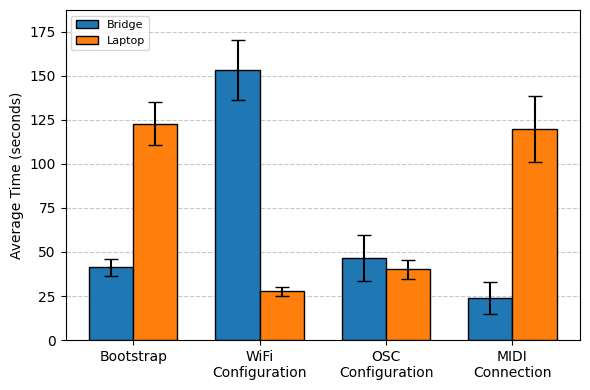

In [281]:
# Plot 1: All timing columns comparison
print("\nCreating complete timing comparison plot...")

x = np.arange(len(all_timing_columns))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=-1)

bars1 = ax.bar(x - width/2, bridge_means_all, width, label='Bridge', edgecolor='black', 
               yerr=bridge_errors_all, capsize=5, zorder=100)
bars2 = ax.bar(x + width/2, laptop_means_all, width, label='Laptop', edgecolor='black', 
               yerr=laptop_errors_all, capsize=5, zorder=100)

ax.set_ylabel('Average Time (seconds)')
ax.set_xticks(x)
ax.set_xticklabels([label_names[e] for e in all_timing_columns], ha='center')
ax.legend(loc='upper left')
ax.set_ylim(0, max(max(bridge_means_all + bridge_errors_all), 
                   max(laptop_means_all + laptop_errors_all)) * 1.1)

plt.tight_layout()
plt.savefig(os.path.join(outdir, "timing_all.pdf"), dpi=300, bbox_inches='tight')
plt.show()


=== TIMING STATISTICS (Selected Columns) ===

# Users: 9

Bridge Averages:
 1. Bootstrap: 41.28 ± 4.76 seconds
 2. Wifi+OSC: 199.78 ± 25.97 seconds
 3. MIDI Connection: 23.89 ± 9.29 seconds
 4. Tot: 264.94 ± 34.59 seconds

Laptop Averages:
 1. Bootstrap: 122.67 ± 12.19 seconds
 2. Wifi+OSC: 67.89 ± 6.08 seconds
 3. MIDI Connection: 119.67 ± 18.85 seconds
 4. Tot: 310.22 ± 31.90 seconds

Creating selected timing comparison plot...


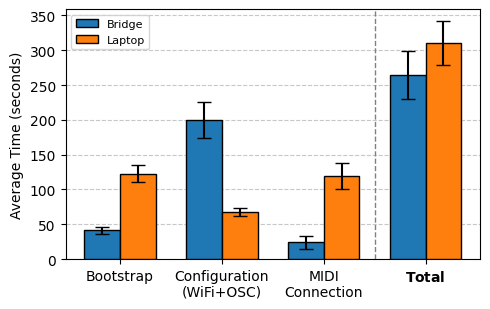


Plots saved to 'plots' directory!


In [282]:

# Calculate statistics for selected timing columns
bridge_means_sel, bridge_errors_sel = calculate_stats(bridge_data, selected_timing_columns)
laptop_means_sel, laptop_errors_sel = calculate_stats(laptop_data, selected_timing_columns)


def plot_timing(bridge_means_sel, bridge_errors_sel,
                laptop_means_sel, laptop_errors_sel, 
                columns=selected_timing_columns, showtot=True, plot_type=None,
                fname="out.pdf"):
    print("\n=== TIMING STATISTICS (Selected Columns) ===")

    print("\n# Users:",'%d'%(len(bridge_data)/2))

    if showtot == False:
        # Drop columns that contain word 'Tot'
        columns = [col for col in columns if 'Tot' not in col]
        bridge_means_sel = bridge_means_sel[columns]
        bridge_errors_sel = bridge_errors_sel[columns]
        laptop_means_sel = laptop_means_sel[columns]
        laptop_errors_sel = laptop_errors_sel[columns]

    print("\nBridge Averages:")
    for i, (col, mean) in enumerate(bridge_means_sel.items()):
        print(f"{i+1:2d}. {col}: {mean:.2f} ± {bridge_errors_sel.iloc[i]:.2f} seconds")

    print("\nLaptop Averages:")
    for i, (col, mean) in enumerate(laptop_means_sel.items()):
        print(f"{i+1:2d}. {col}: {mean:.2f} ± {laptop_errors_sel.iloc[i]:.2f} seconds")

    # Plot 2: Selected timing columns comparison
    print("\nCreating selected timing comparison plot...")

    x = np.arange(len(columns))
    width = 0.35

    fig, ax = plt.subplots(figsize=(5, 3.2))
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=-1)

    bars1 = ax.bar(x - width/2, bridge_means_sel, width, label='Bridge', edgecolor='black', 
                yerr=bridge_errors_sel, capsize=5, zorder=100)
    bars2 = ax.bar(x + width/2, laptop_means_sel, width, label='Laptop', edgecolor='black', 
                yerr=laptop_errors_sel, capsize=5, zorder=100)

    if showtot:
        # // Dashed vertical line between the last two bars
        ax.axvline((x[-2]+x[-1])/2, color='gray', linestyle='--', linewidth=1, zorder=50)

    if plot_type == 'delta':
        ax.set_ylabel('Average Time Difference (seconds)')
    else:
        ax.set_ylabel('Average Time (seconds)')
    ax.set_xticks(x)
    ax.set_xticklabels([label_names[e] for e in columns], ha='center')
    ax.legend()
    # ax.set_ylim(0, max(max(bridge_means_sel + bridge_errors_sel), 
    #                 max(laptop_means_sel + laptop_errors_sel)) * 1.1)

    # yticks_mins = np.arange(0, ax.get_ylim()[1], 60)
    # ax.set_yticks(yticks_mins)

    plt.tight_layout()
    plt.savefig(os.path.join(outdir, fname), dpi=300, bbox_inches='tight')
    plt.show()

plot_timing(bridge_means_sel, bridge_errors_sel, laptop_means_sel, laptop_errors_sel, fname="timing_compact.pdf")

print("\nPlots saved to 'plots' directory!")

In [283]:
delta_array[0]

,User ID,Device,Wifi+OSC,Tot,Delta_Bootstrap,Delta_WiFi_Config,Delta_OSC_Config,Delta_MIDI_Connection,Delta_WifiAndOSC_Config,Delta_Tot
1,1,Laptop,45,164,-12.0,-44.0,-14.0,-195.0,-58.0,-265.0
3,2,Laptop,31,173,-48.0,-5.0,-49.0,-180.0,-54.0,-282.0
5,3,Laptop,43,183,-40.0,-6.0,-49.0,-129.0,-55.0,-224.0
7,4,Laptop,41,242,42.0,-1.0,-30.0,-72.0,-31.0,-61.0
9,5,Laptop,39,205,-37.0,-4.0,-39.0,-42.0,-43.0,-122.0
11,6,Laptop,64,242,67.0,25.0,-50.0,-128.0,-25.0,-86.0
13,7,Laptop,71,318,-148.0,-4.0,-46.0,-197.0,-50.0,-395.0
15,8,Laptop,58,217,-18.0,13.0,-28.0,-75.0,-15.0,-108.0
17,9,Laptop,34,187,-84.0,-9.0,-30.0,-56.0,-39.0,-179.0


In [284]:
data_array[0]

,User ID,Device,Room,Bootstrap,WiFi Config,OSC Configuration,MIDI Connection,Wifi+OSC,Tot
0,1,Laptop,1,82,54,49,244,103,429
1,1,Laptop,2,70,10,35,49,45,164
2,2,Laptop,1,144,27,58,226,85,455
3,2,Laptop,2,96,22,9,46,31,173
4,3,Laptop,1,124,33,65,185,98,407
5,3,Laptop,2,84,27,16,56,43,183
6,4,Laptop,1,123,24,48,108,72,303
7,4,Laptop,2,165,23,18,36,41,242
8,5,Laptop,1,114,21,61,131,82,327
9,5,Laptop,2,77,17,22,89,39,205



=== TIMING STATISTICS (Selected Columns) ===

# Users: 9

Bridge Averages:
 1. Delta_Bootstrap: -20.78 ± 7.84 seconds
 2. Delta_WifiAndOSC_Config: -114.89 ± 48.29 seconds
 3. Delta_MIDI_Connection: -23.56 ± 18.62 seconds

Laptop Averages:
 1. Delta_Bootstrap: -30.89 ± 21.20 seconds
 2. Delta_WifiAndOSC_Config: -41.11 ± 4.97 seconds
 3. Delta_MIDI_Connection: -119.33 ± 20.35 seconds

Creating selected timing comparison plot...


C:\Users\cimil\AppData\Local\Temp\ipykernel_25192\2584431039.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataff = idataff.groupby('User ID').apply(
C:\Users\cimil\AppData\Local\Temp\ipykernel_25192\2584431039.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataff = idataff.groupby('User ID').apply(


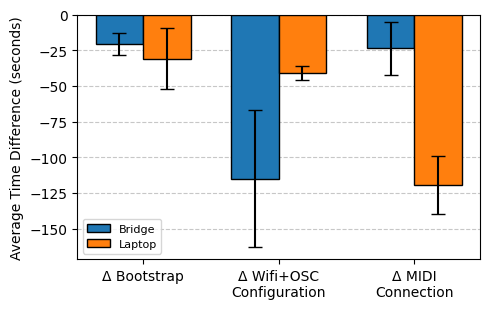

In [285]:
# Now compute first the delta for each User ID between Room1 and Room2, for both Bridge and Laptop

data_array = (laptop_data, bridge_data)
delta_array = [None, None]
for i, idataff in enumerate(data_array):
    
    dataff = idataff.groupby('User ID').apply(
        lambda x: x.assign(
            Delta_Bootstrap=x['Bootstrap'].diff(),
            Delta_WiFi_Config=x['WiFi Config'].diff(),
            Delta_OSC_Config=x['OSC Configuration'].diff(),
            Delta_MIDI_Connection=x['MIDI Connection'].diff(),
            Delta_WifiAndOSC_Config=x['Wifi+OSC'].diff(),
            Delta_Tot=x['Tot'].diff()
        ) 
    ).reset_index(drop=True)

    # drop selected columns
    dataff = dataff.drop(columns=all_timing_columns+['Room'])
    # Drop all rows where Delta_Tot is NaN (which will be the first row for each User ID)
    dataff = dataff.dropna(subset=['Delta_Tot'])
    delta_array[i] = dataff

# display(delta_array[0])

# Statistics
bridge_delta_means, bridge_delta_errors = calculate_stats(delta_array[1], selected_delta_columns)
laptop_delta_means, laptop_delta_errors = calculate_stats(delta_array[0], selected_delta_columns)

# extract selected_delta_columns
plot_timing(bridge_delta_means[selected_delta_columns],
            bridge_delta_errors[selected_delta_columns], 
            laptop_delta_means[selected_delta_columns], 
            laptop_delta_errors[selected_delta_columns], 
            columns=selected_delta_columns,
            showtot = False,
            plot_type='delta',
            fname="timing_deltas.pdf")


Creating timing comparison with stacked bars for both devices...


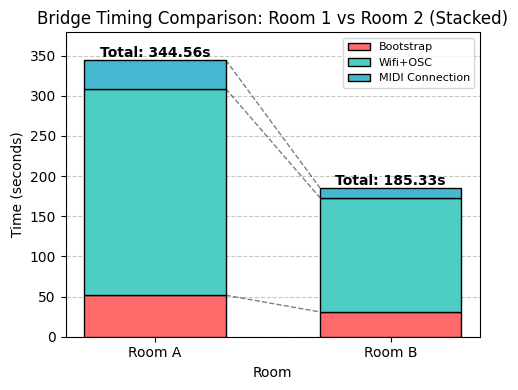

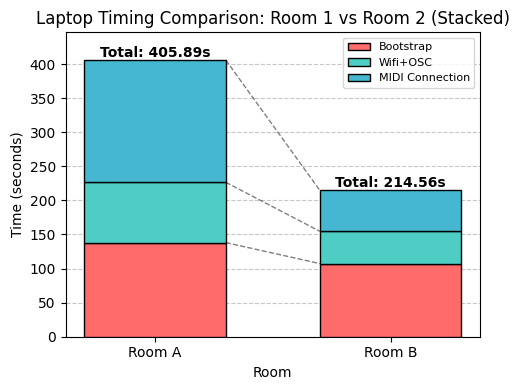

In [286]:
# Plot: Timing comparison between Room 1 and Room 2 with stacked bars for both devices
print("\nCreating timing comparison with stacked bars for both devices...")

timing_components = selected_timing_columns
# Remove Tot
if 'Tot' in timing_components:
    timing_components.remove('Tot')
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for data, device_name in zip([bridge_data, laptop_data], ['Bridge', 'Laptop']):
    # Extract data for Room 1 and Room 2
    room1_data = data[data['Room'] == 1]
    room2_data = data[data['Room'] == 2]
    
    # Calculate means for each component
    room1_means = [room1_data[col].mean() for col in timing_components]
    room2_means = [room2_data[col].mean() for col in timing_components]
    
    # Calculate standard errors
    room1_errors = [room1_data[col].sem() for col in timing_components]
    room2_errors = [room2_data[col].sem() for col in timing_components]
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=-1)
    
    x_pos = [0, 1]
    width = 0.6
    
    # Create stacked bars
    bottom_room1 = 0
    bottom_room2 = 0
    bars_room1 = []
    bars_room2 = []
    
    for i, (component, color) in enumerate(zip(timing_components, colors)):
        # Room 1 bars
        bar1 = ax.bar(x_pos[0], room1_means[i], width, bottom=bottom_room1, 
                      label=component, color=color, edgecolor='black', alpha=1, zorder=10)
        bars_room1.append(bar1)
        bottom_room1 += room1_means[i]
        
        # Room 2 bars
        bar2 = ax.bar(x_pos[1], room2_means[i], width, bottom=bottom_room2, 
                      color=color, edgecolor='black', alpha=1, zorder=10)
        bars_room2.append(bar2)
        bottom_room2 += room2_means[i]
    
    # Add connecting lines between bar terminations
    for i,c in enumerate(timing_components):
        # print(f"Connecting {c} between Room 1 and Room 2")
        y1 = sum(room1_means[:i+1])
        y2 = sum(room2_means[:i+1])
        # print(f"Connecting {c} at y1={y1:.2f}, y2={y2:.2f}")
        ax.plot([x_pos[0] + width/2, x_pos[1] - width/2], [y1, y2], 
                'k--', alpha=0.5, linewidth=1)
    
    # Customize the plot
    ax.set_ylabel('Time (seconds)')
    ax.set_xlabel('Room')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Room A', 'Room B'])
    ax.legend()
    ax.set_title(f'{device_name} Timing Comparison: Room 1 vs Room 2 (Stacked)')

    ax.set_ylim(0, max(bottom_room1, bottom_room2) * 1.1)
    
    # Add total time annotations
    ax.text(x_pos[0], bottom_room1 + 0.1, f'Total: {bottom_room1:.2f}s', 
            ha='center', va='bottom', fontweight='bold')
    ax.text(x_pos[1], bottom_room2 + 0.1, f'Total: {bottom_room2:.2f}s', 
            ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


Creating timing comparison with stacked bars for both devices...


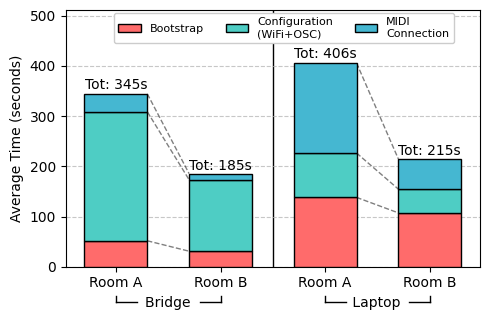

In [287]:
# Plot: Timing comparison between Room 1 and Room 2 with stacked bars for both devices
print("\nCreating timing comparison with stacked bars for both devices...")

timing_components = selected_timing_columns
# Remove Tot
if 'Tot' in timing_components:
    timing_components.remove('Tot')
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Create a single figure
fig, ax = plt.subplots(figsize=(5, 3.3))
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=-1)

# Define positions for the 4 bars: Laptop Room1, Laptop Room2, Bridge Room1, Bridge Room2
x_pos = [0, 1, 2, 3]  # Gap between laptop and bridge
width = 0.6

# Process both devices
devices_data = []
for data, device_name in zip([laptop_data, bridge_data], ['Laptop', 'Bridge']):
    # Extract data for Room 1 and Room 2
    room1_data = data[data['Room'] == 1]
    room2_data = data[data['Room'] == 2]
    
    # Calculate means for each component
    room1_means = [room1_data[col].mean() for col in timing_components]
    room2_means = [room2_data[col].mean() for col in timing_components]
    
    devices_data.append({
        'name': device_name,
        'room1_means': room1_means,
        'room2_means': room2_means
    })

# Create stacked bars for all 4 conditions
bottoms = [0, 0, 0, 0]  # Bottom positions for stacking
all_bars = [[], [], [], []]  # Store bars for each condition

for i, (component, color) in enumerate(zip(timing_components, colors)):
    
    # Bridge Room 1
    bar3 = ax.bar(x_pos[0], devices_data[1]['room1_means'][i], width, 
                  bottom=bottoms[0], color=color, edgecolor='black', alpha=1, zorder=10)
    all_bars[0].append(bar3)
    bottoms[0] += devices_data[1]['room1_means'][i]
    
    # Bridge Room 2
    bar4 = ax.bar(x_pos[1], devices_data[1]['room2_means'][i], width, 
                  bottom=bottoms[1], color=color, edgecolor='black', alpha=1, zorder=10)
    all_bars[1].append(bar4)
    bottoms[1] += devices_data[1]['room2_means'][i]

    # Laptop Room 1
    component_label = label_names[component]
    bar1 = ax.bar(x_pos[2], devices_data[0]['room1_means'][i], width, 
                  bottom=bottoms[2], label=component_label,
                  color=color, edgecolor='black', alpha=1, zorder=10)
    all_bars[2].append(bar1)
    bottoms[2] += devices_data[0]['room1_means'][i]
    
    # Laptop Room 2
    bar2 = ax.bar(x_pos[3], devices_data[0]['room2_means'][i], width, 
                  bottom=bottoms[3], color=color, edgecolor='black', alpha=1, zorder=10)
    all_bars[3].append(bar2)
    bottoms[3] += devices_data[0]['room2_means'][i]
    


# Vertical dashed line between Laptop and Bridge
# ax.axvline((x_pos[1] + x_pos[2]) / 2 , color='gray', linestyle='--', linewidth=1, zorder=-1)
ax.axvline((x_pos[1] + x_pos[2]) / 2 , color='k', linewidth=1, zorder=-1)

# Add connecting lines between corresponding segments
# Laptop Room 1 to Room 2
for i, c in enumerate(timing_components):
    # print(f"Connecting {c} between Laptop Room 1 and Room 2")
    y1 = sum(devices_data[0]['room1_means'][:i+1])
    y2 = sum(devices_data[0]['room2_means'][:i+1])
    # print(f"Connecting {c} at y1={y1:.2f}, y2={y2:.2f}")
    ax.plot([x_pos[2] + width/2, x_pos[3] - width/2], [y1, y2], 
            'k--', alpha=0.5, linewidth=1)

# Bridge Room 1 to Room 2
for i, c in enumerate(timing_components):
    # print(f"Connecting {c} between Bridge Room 1 and Room 2")
    y1 = sum(devices_data[1]['room1_means'][:i+1])
    y2 = sum(devices_data[1]['room2_means'][:i+1])
    # print(f"Connecting {c} at y1={y1:.2f}, y2={y2:.2f}")
    ax.plot([x_pos[0] + width/2, x_pos[1] - width/2], [y1, y2], 
            'k--', alpha=0.5, linewidth=1)

# Customize the plot
ax.set_ylabel('Average Time (seconds)')
ax.set_xticks(x_pos)
# ax.set_xticklabels(['Laptop\nRoom 1', 'Laptop\nRoom 2', 'Bridge\nRoom 1', 'Bridge\nRoom 2'])
ax.set_xticklabels(['Room A', 'Room B', 'Room A', 'Room B'])
ax.set_xlabel('Bridge                                     Laptop')
plt.rc('legend',fontsize=8) # using a size in points

ax.set_ylim(0, max(bottoms) * 1.26)
# ax.set_xlim(-0.5, 4.2)

def draw_short_hor_bracket(xstart,xend,y,ax,color='gray',linewidth=1, ends_height = 10, centerhole = 0):
    # lineout = ax.plot([xstart,xend],[y,y],c=color,linewidth=linewidth)
    # lineout[0].set_clip_on(False)

    if centerhole > 0:
        # Draw the horizontal line with a gap in the middle
        lineout = ax.plot([xstart, xstart + centerhole], [y, y], c=color, linewidth=linewidth)
        lineout[0].set_clip_on(False)
        lineout = ax.plot([xend - centerhole, xend], [y, y], c=color, linewidth=linewidth)
        lineout[0].set_clip_on(False)
    else:
        # Draw the horizontal line without a gap
        lineout = ax.plot([xstart, xend], [y, y], c=color, linewidth=linewidth)
        lineout[0].set_clip_on(False)


    # Draw the ends
    lineout = ax.plot([xstart,xstart],[y,y+ends_height],c=color,linewidth=linewidth)
    lineout[0].set_clip_on(False)
    lineout = ax.plot([xend,xend],[y,y+ends_height],c=color,linewidth=linewidth)
    lineout[0].set_clip_on(False)

draw_short_hor_bracket(x_pos[0], x_pos[1], -70, ax, color='black', linewidth=1, ends_height=12, centerhole=0.2)
draw_short_hor_bracket(x_pos[2], x_pos[3], -70, ax, color='black', linewidth=1, ends_height=12, centerhole=0.2)


# Add total time annotations
for i, (pos, total) in enumerate(zip(x_pos, bottoms)):
    ax.text(pos, total*1.01, f'Tot: {total:.0f}s', 
            ha='center', va='bottom')
ax.legend(loc='upper right', ncol=3, bbox_to_anchor=(.95, 1.01),facecolor='white', framealpha=1)

plt.tight_layout()
plt.savefig(os.path.join(outdir, "timing_deltas_stacked.pdf"), dpi=300, bbox_inches='tight')
plt.show()